In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

thực hiện import các thư viện cần thiết cho cả bài làm


 THÔNG TIN TỔNG QUÁT CỦA BỘ DỮ LIỆU
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42639 entries, 0 to 42638
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID            42639 non-null  int64 
 1   age           42639 non-null  int64 
 2   job           42639 non-null  object
 3   marital       42639 non-null  int64 
 4   education     42639 non-null  object
 5   default       42639 non-null  int64 
 6   balance       42639 non-null  int64 
 7   housing       42639 non-null  int64 
 8   loan          42639 non-null  int64 
 9   day           42639 non-null  int64 
 10  month         42639 non-null  object
 11  duration      42639 non-null  int64 
 12  campaign      42639 non-null  int64 
 13  pdays         42639 non-null  int64 
 14  previous      42639 non-null  int64 
 15  term_deposit  42639 non-null  int64 
dtypes: int64(13), object(3)
memory usage: 5.2+ MB
None

 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU
   ID  ag

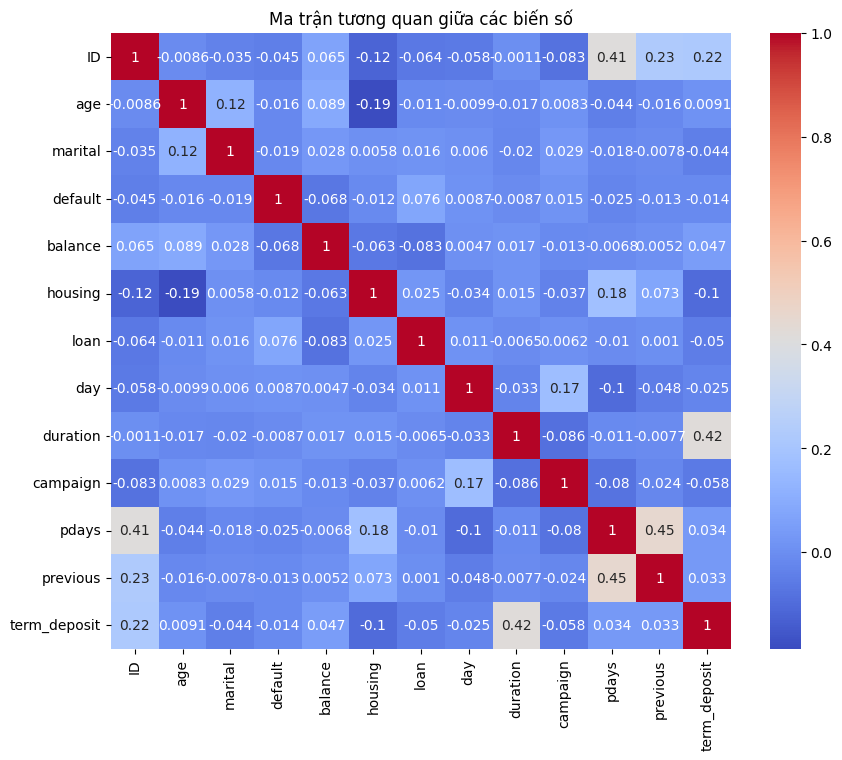

In [ ]:
# 1.1 THU THẬP VÀ TẢI DỮ LIỆU
df=pd.read_csv('BankCustomerData.csv')
print('\n THÔNG TIN TỔNG QUÁT CỦA BỘ DỮ LIỆU')
print(df.info())
print('\n 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU')
print(df.head())

#1.2. PHÂN TÍCH DỮ LIỆU
#1.2.1 THỐNG KÊ MÔ TẢ
print('------THỐNG KÊ MÔ TẢ------')
thong_ke= df.describe()
print(thong_ke)

#1.2.2. MỐI QUAN HỆ TƯƠNG QUAN GIỮA CÁC BIẾN
numeric_cols = df.select_dtypes(include='number')
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

- Tập dữ liệu được lấy từ trang công khai Kaggle, bao gồm 42639 quan sát và 16 biến, trong đó có 13 biến dạng số (int64) và 3 biến dạng chuỗi (object)
- Các biến chứa thông tin cá nhân và hành vi của khách hàng như tuổi(age), nghề nghiệp (job), tình trạng hôn nhân (marital), trình độ học vấn (education), số dư tài khoản (balance), tình trạng vay nợ (loan, housing, default), cũng như các thông tin liên quan đến chiến dịch tiếp thị như thời lượng cuộc gọi (duration), số lần liên hệ (campaign), số ngày kể từ lần liên hệ trước (pdays), số lần liên hệ trước đó (previous). Biến mục tiêu term_deposit cho biết khách hàng có (1) hoặc không (0) đăng ký tiền gửi có kỳ hạn
- Trong 5 dòng đầu tiên của tập dữ liệu, quan sát được rằng với mỗi hàng là thông tin của 1 khách hàng duy nhất, được định danh bằng biến ID. Một số giá trị bị khuyết trong các biến phân loại như 'job', 'education' được thể hiện qua nhãn 'unknown'
-Biểu đồ Heatmap:
  - biến duration có tương quan dương khá cao, khả năng khách hàng đăng ký tiền gửi có kỳ hạn term_deposit: thời lượng cuộc gọi tiếp thị càng dài, khả năng khách hàng đồng ý đăng ký tiền gửi có kỳ hạn càng cao. Đây là biến quan trọng, dễ lý giải vì thời gian trao đổi nhiều thường đồng nghĩa với sự quan tâm
  - biến balance có tương quan dương khá yếu (0.063): khách hàng có số dư cao hơn một chút thì khả năng đăng ký tăng, nhưng mức ảnh hưởng rất thấp
các biến age, default, housing, loan, day, campaign, pdays, previous hầu như không có tương quan đáng kể với term_deposit

In [ ]:
# 1.3 TIỀN XỬ LÝ VÀ LÀM SẠCH DỮ LIỆU
#1.3.1. KIỂM TRA DỮ LIỆU
print('KIỂM TRA DỮ LIỆU RỖNG')
print(df.isnull().sum())
print('\n KIỂM TRA SỐ DÒNG TRÙNG LẶP:', df.duplicated().sum())

# 1.3.2 XỬ LÝ NGOẠI LỆ Outliers
# Xử lý outliers AGE
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
 # giữ lại các dòng có giá trị trong khoảng cho phép
df = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

 #xử lý outliers Balance
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)]

 #Xử lý outliers duration
Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['duration'] >= lower_bound) & (df['duration'] <= upper_bound)]

print('\n KÍCH THƯỚC SAU KHI KIỂM TRA, XỬ LÝ NGOẠI LỆ')
print(df.shape)

KIỂM TRA DỮ LIỆU RỖNG
ID              0
age             0
job             0
marital         0
education       0
default         0
balance         0
housing         0
loan            0
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
term_deposit    0
dtype: int64

 KIỂM TRA SỐ DÒNG TRÙNG LẶP: 0

 KÍCH THƯỚC SAU KHI KIỂM TRA, XỬ LÝ NGOẠI LỆ
(35030, 16)


- Bước đầu tiên của tiền xử lý là sử dụng df.isnull().sum() và df.duplicated().sum() để kiểm tra giá trị thiếu và dòng trùng lặp trong tập dữ liệu cho thấy không có hàng nào chứa giá trị rỗng (missing values) hay dòng trùng lặp.
- Tiếp theo là xử lý ngoại lệ của các biến định lượng 'age', 'balance', 'duration'



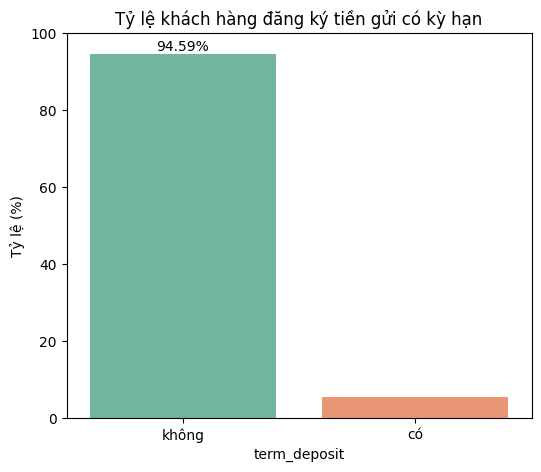

In [ ]:
#2.1.1. TỶ LỆ KHÁCH HÀNG ĐĂNG KÝ TIỀN GỬI CÓ KỲ HẠN
# Tính tỷ lệ phần trăm
deposit_percent = df['term_deposit'].value_counts(normalize=True) * 100
deposit_df = deposit_percent.reset_index()
deposit_df.columns = ['term_deposit', 'percent']
# Vẽ biểu đồ
plt.figure(figsize=(6, 5))
ax = sns.barplot(data=deposit_df, x='term_deposit', y='percent', hue='term_deposit', palette='Set2', legend=False)
# Gắn nhãn phần trăm lên từng cột
ax.bar_label(container=ax.containers[0], fmt="%.2f%%")

plt.title('Tỷ lệ khách hàng đăng ký tiền gửi có kỳ hạn')
plt.ylabel('Tỷ lệ (%)')
plt.xlabel('term_deposit')
plt.ylim(0, 100)
plt.show()

Biểu đồ cột cho thấy sự mất cân bằng trong dữ liệu khi 94.59% khách hàng không đăng ký, trong khi chỉ có 5.41% đăng ký tiền gửi có kỳ hạn. Sự chênh lệch này khiến chỉ số độ chính xác (accuracy) trở nên vô nghĩa, vì mô hình có thể đạt kết quả cao chỉ bằng cách luôn dự đoán "không đăng ký", bỏ qua lớp thiểu số. Do đó, cần phải xử lý dữ liệu mất cân bằng bằng các kỹ thuật như oversampling, undersampling hoặc điều chỉnh trọng số lớp để mô hình học hiệu quả hơn và dự đoán chính xác cả hai lớp.

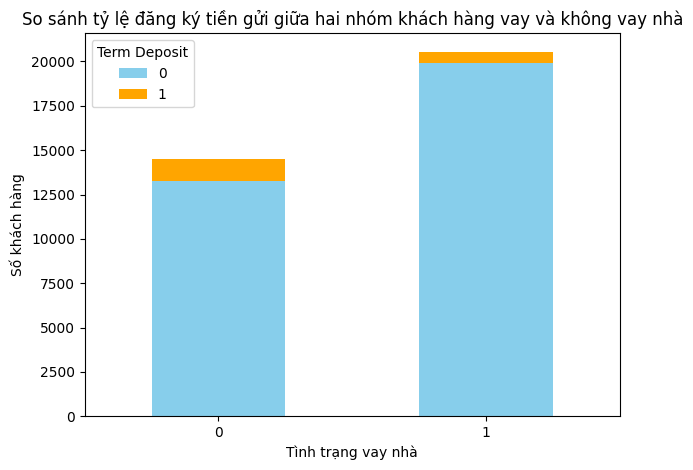

In [ ]:
# 2.1.2.SO SÁNH TỶ LỆ ĐĂNG KÝ TIỀN GỬI GIỮA 2 NHÓM KHÁCH HÀNG VAY VÀ KHÔNG VAY NHÀ
# Đếm số lượng khách hàng theo từng nhóm housing và term_deposit
housing_counts = df.groupby(['housing', 'term_deposit']).size().unstack(fill_value=0)
# Vẽ biểu đồ cột chồng
housing_counts.plot(kind='bar', stacked=True, color=['skyblue', 'orange'])

plt.title('So sánh tỷ lệ đăng ký tiền gửi giữa hai nhóm khách hàng vay và không vay nhà')
plt.xlabel('Tình trạng vay nhà')
plt.ylabel('Số khách hàng')
plt.legend(title='Term Deposit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Phân tích cho thấy có sự mất cân bằng trong dữ liệu về việc vay nhà, với số lượng khách hàng có vay nhà (cột 1) nhiều hơn đáng kể. Tuy nhiên, nhóm khách hàng không vay nhà (cột 0) lại có tỷ lệ đăng ký tiền gửi cao hơn. Điều này cho thấy tồn tại mối tương quan rõ ràng giữa biến "housing" và việc đăng ký tiền gửi. Do đó, biến "housing" được xác định là một đặc trưng quan trọng và có sức mạnh dự đoán cao, cần được đưa vào mô hình học máy để cải thiện hiệu quả dự đoán.

/tmp/ipython-input-3055913249.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='term_deposit', y='duration', data=df, palette='Set2')


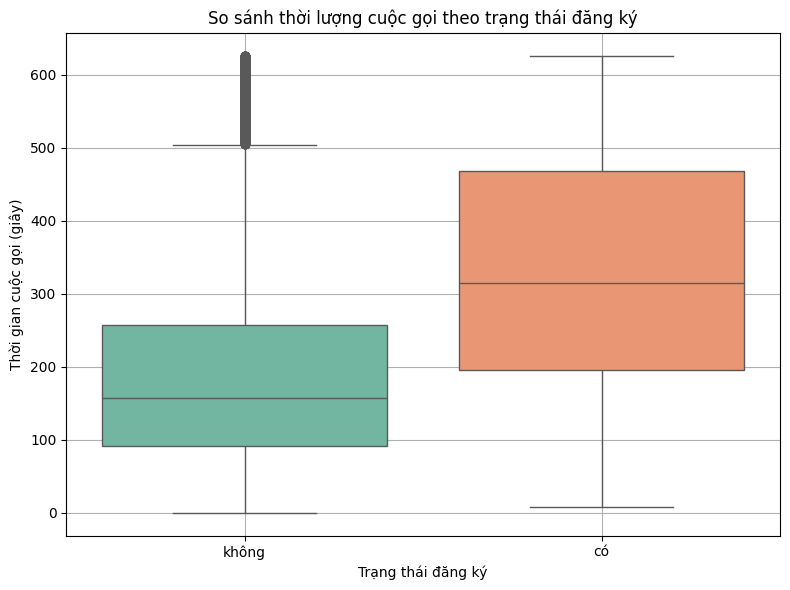

In [ ]:
# 2.1.3. SO SÁNH THỜI LƯỢNG CUỘC GỌI THEO TRẠNG THÁI ĐĂNG KÝ TIỀN GỬI
df['term_deposit'] = df['term_deposit'].replace({0: 'không', 1: 'có'})
# Vẽ boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='term_deposit', y='duration', data=df, palette='Set2')

plt.title('So sánh thời lượng cuộc gọi theo trạng thái đăng ký')
plt.xlabel('Trạng thái đăng ký')
plt.ylabel('Thời gian cuộc gọi (giây)')
plt.grid(True)
plt.tight_layout()
plt.show()

Biểu đồ hộp cho thấy có sự khác biệt rõ rệt về thời lượng cuộc gọi giữa hai nhóm khách hàng. Những người đồng ý đăng ký tiền gửi có kỳ hạn thường có thời gian gọi trung bình và trung vị cao hơn đáng kể so với những người không đăng ký. Điều này cho thấy có mối liên hệ chặt chẽ giữa thời gian cuộc gọi và quyết định đăng ký của khách hàng, biến "duration" trở thành một đặc trưng dự đoán mạnh mẽ. Việc đưa biến này vào mô hình học máy sẽ giúp phân biệt hiệu quả hơn giữa khách hàng tiềm năng và không tiềm năng, từ đó nâng cao độ chính xác của mô hình.

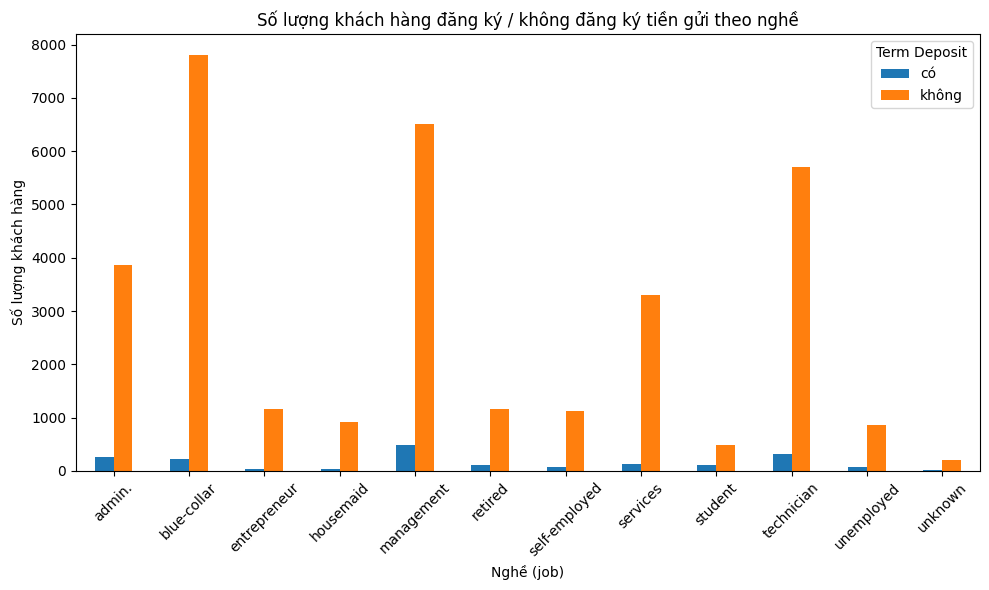

In [ ]:
# 2.1.4. SO SÁNH KHÁCH HÀNG CÓ HAY KHÔNG ĐĂNG KÝ TIỀN GỬI THEO NGHỀ NGHIỆP
# Đếm số lượng theo 'job' và 'term_deposit'
job_counts = df.groupby(['job', 'term_deposit']).size().unstack(fill_value=0)

# Vẽ biểu đồ cột
job_counts.plot(kind='bar', figsize=(10, 6))
plt.title("Số lượng khách hàng đăng ký / không đăng ký tiền gửi theo nghề")
plt.xlabel("Nghề (job)")
plt.ylabel("Số lượng khách hàng")
plt.xticks(rotation=45)
plt.legend(title="Term Deposit")
plt.tight_layout()
plt.show()

- Có sự khác biệt rõ rệt về thời lượng cuộc gọi giữa hai nhóm khách hàng. Những người đồng ý đăng ký tiền gửi có kỳ hạn thường có thời gian gọi trung bình và trung vị cao hơn đáng kể so với những người không đăng ký.
- Điều này cho thấy có mối liên hệ chặt chẽ giữa thời gian cuộc gọi và quyết định đăng ký của khách hàng, biến "duration" trở thành một đặc trưng dự đoán mạnh mẽ. Việc đưa biến này vào mô hình học máy sẽ giúp phân biệt hiệu quả hơn giữa khách hàng tiềm năng và không tiềm năng, từ đó nâng cao độ chính xác của mô hình.

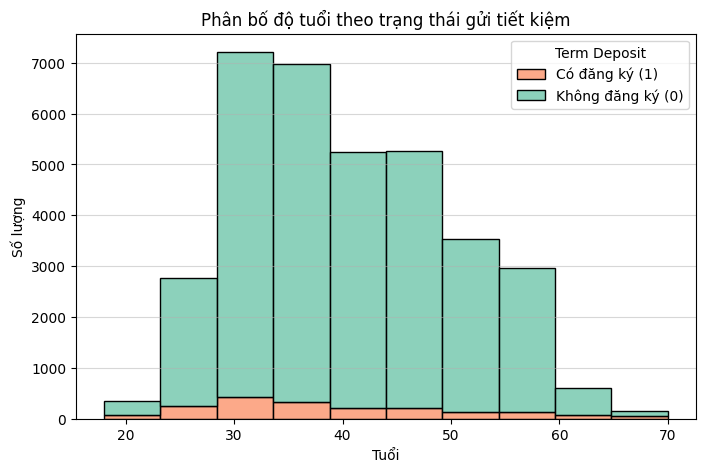

In [ ]:
# 2.1.5. PHÂN BỐ ĐỘ TUỔI THEO TRẠNG THÁI GỬI TIẾT KIỆM
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='term_deposit', bins=10, kde=False, palette='Set2', multiple='stack', edgecolor='black')

plt.title('Phân bố độ tuổi theo trạng thái gửi tiết kiệm')
plt.xlabel('Tuổi')
plt.ylabel('Số lượng')
plt.grid(axis='y', alpha=0.5)
plt.legend(title='Term Deposit', labels=['Có đăng ký (1)', 'Không đăng ký (0)'])
plt.show()

- Phần lớn khách hàng tập trung ở độ tuổi 30-50, nhóm có thu nhập ổn định. Nhóm khách hàng dưới 40 tuổi và trên 60 tuổi thể hiện tỷ lệ đăng ký tiền gửi cao, cho thấy sự quan tâm đến các sản phẩm tài chính.
- Đặc điểm này chứng tỏ biến 'age' là một đặc trưng quan trọng có sức mạnh dự đoán, vì nó có liên quan trực tiếp đến hành vi đăng ký tiền gửi. Do đó, mô hình học máy nên sử dụng biến 'age' để cải thiện hiệu quả dự đoán.

/tmp/ipython-input-3688415368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


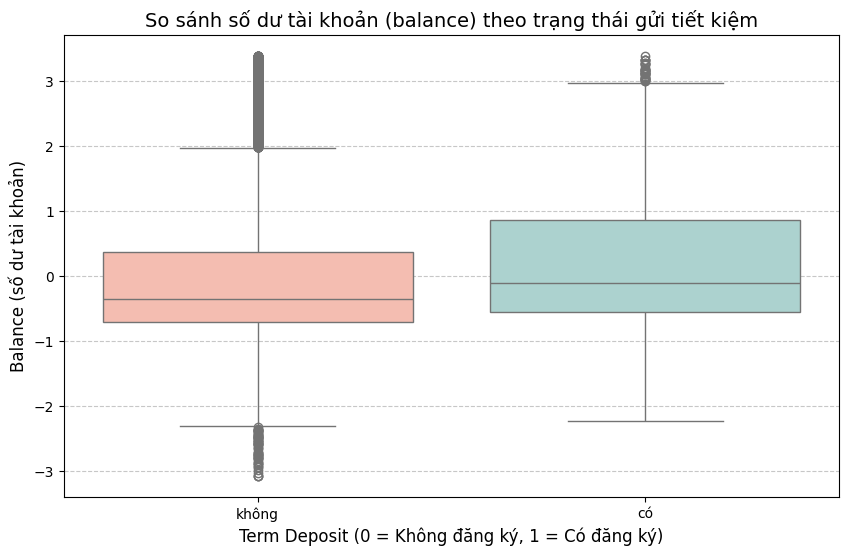

In [ ]:
#2.1.6. SO SÁNH SỐ DƯ TÀI KHOẢN THEO TRẠNG THÁI GỬI TIẾT KIỆM
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='term_deposit',
    y='balance',
    palette=['#FFB6A6', '#A6D8D4']
)

plt.title('So sánh số dư tài khoản (balance) theo trạng thái gửi tiết kiệm', fontsize=14)
plt.xlabel('Term Deposit (0 = Không đăng ký, 1 = Có đăng ký)', fontsize=12)
plt.ylabel('Balance (số dư tài khoản)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


- Có sự khác biệt rõ rệt về số dư tài khoản (balance) giữa hai nhóm khách hàng. Những khách hàng đăng ký tiền gửi có kỳ hạn thường có số dư tài khoản trung vị cao hơn đáng kể so với nhóm không đăng ký. Điều này chỉ ra rằng, số dư tài khoản là một đặc trưng quan trọng và có sức mạnh dự đoán cao.
- Việc đưa biến "balance" vào mô hình học máy sẽ giúp phân biệt hiệu quả giữa khách hàng tiềm năng và không tiềm năng, từ đó nâng cao độ chính xác của mô hình dự đoán.

In [ ]:
# 2.2. XÂY DỰNG MÔ HÌNH HỌC MÁY MACHINE LEARNING
# 2.2.1 MÃ HÓA VÀ CHUẨN HÓA DỮ LIỆU

# Mã hóa
# Loại bỏ cột ID (không có ý nghĩa dự đoán)
df = df.drop(columns=['ID'])

#  Xác định các cột phân loại (categorical) cần One-hot encoding
#  Bao gồm cả các biến category dạng số như marital
categorical_cols = ['job', 'education', 'marital', 'month']

#  One-hot encoding (drop_first=True để tránh đa cộng tuyến)
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#Chuẩn hóa
# Xác định các cột số (numeric) cần chuẩn hóa
#    Loại bỏ các biến nhị phân và biến mục tiêu
exclude_cols = [
    'term_deposit',  # biến mục tiêu
    'housing',       # nhị phân 0/1
    'loan',          # nhị phân 0/1
    'default'        # nhị phân 0/1
]
numeric_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns
                if col not in exclude_cols]

# Chuẩn hóa các biến số
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Kích thước dữ liệu sau mã hóa và chuẩn hóa:", df.shape)
print(df.head())

Kích thước dữ liệu sau mã hóa và chuẩn hóa: (35030, 38)
        age  default   balance  housing  loan       day  duration  campaign  \
0  1.824756        0  1.907025        1     0 -1.293731  0.460081 -0.573113   
1  0.380631        0 -0.704689        1     0 -1.293731 -0.343964 -0.573113   
2 -0.754039        0 -0.738046        1     1 -1.293731 -0.892176 -0.573113   
3  0.690086        0  1.120051        1     0 -1.293731 -0.775224 -0.573113   
4 -0.754039        0 -0.739282        0     0 -1.293731 -0.000417 -0.573113   

      pdays  previous  ... month_dec  month_feb  month_jan  month_jul  \
0 -0.383114 -0.206584  ...     False      False      False      False   
1 -0.383114 -0.206584  ...     False      False      False      False   
2 -0.383114 -0.206584  ...     False      False      False      False   
3 -0.383114 -0.206584  ...     False      False      False      False   
4 -0.383114 -0.206584  ...     False      False      False      False   

   month_jun  month_mar  month

- Trước khi xây dựng mô hình dự đoán, dữ liệu được tiền xử lý qua các bước chính. Đầu tiên, cột "ID" được loại bỏ vì không có giá trị dự đoán. Tiếp theo, các biến phân loại như 'job', 'education' được mã hóa bằng One-hot encoding với drop_first=True để tránh hiện tượng đa cộng tuyến. Phương pháp này giúp chuyển đổi các biến thành dạng nhị phân, không gán thứ tự sai lệch.
- Cuối cùng, các biến số còn lại được chuẩn hóa bằng StandardScaler, giúp tất cả các biến đều có cùng thang đo, ngăn các biến có giá trị lớn hơn chi phối mô hình. Tóm lại, các bước mã hóa và chuẩn hóa này nhằm tạo ra một tập dữ liệu sạch, phù hợp và hiệu quả nhất cho việc huấn luyện mô hình.
- Sau khi tiền xử lý, sử dụng df.shape để kiểm tra kích thước tập dữ liệu là (35030, 38) và đã sẵn sàng cho mô hình. Các cột số như 'age', 'balance' được chuẩn hóa bằng StandardScaler để có cùng thang đo, trong khi các biến nhị phân như 'default', 'housing' được giữ nguyên. Các biến phân loại như 'month' được mã hóa bằng One-hot encoding thành các cột True/False, giúp mô hình học máy xử lý dữ liệu phi số.

Kích thước tập huấn luyện: (24521, 37)
Kích thước tập kiểm tra: (10509, 37)

Trước SMOTE: term_deposit
0    23194
1     1327
Name: count, dtype: int64
Sau SMOTE: term_deposit
0    23194
1    23194
Name: count, dtype: int64

========== ĐÁNH GIÁ TRÊN TRAIN ==========
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     23194
           1       0.21      0.63      0.31      1327

    accuracy                           0.85     24521
   macro avg       0.59      0.74      0.61     24521
weighted avg       0.93      0.85      0.88     24521

Confusion Matrix:
[[20007  3187]
 [  496   831]]

========== ĐÁNH GIÁ TRÊN TEST ==========
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      9940
           1       0.21      0.60      0.31       569

    accuracy                           0.85     10509
   macro avg       0.59      0.73      0.61     10509
weighted avg       0.93      0.85      0.88 

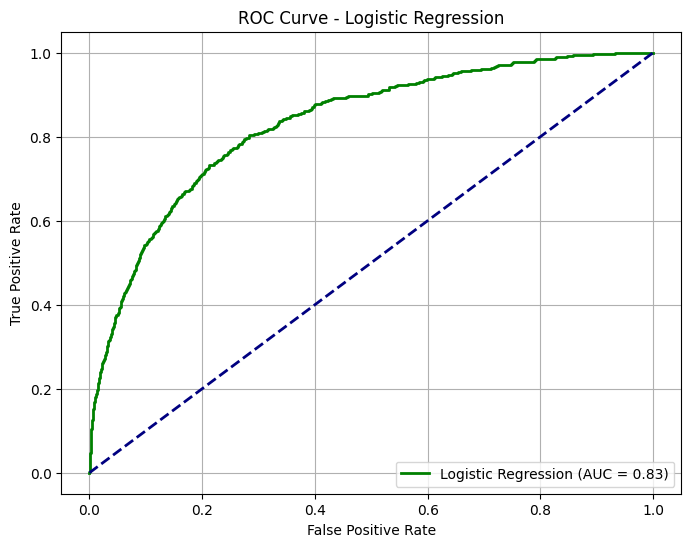

In [ ]:
#2.2.2. MÔ HÌNH HỒI QUY LOGISTIC
# ----------------- TÁCH BIẾN ĐẦU VÀO / RA -----------------
y = df['term_deposit'].map({0: 0, 1: 1, 'có': 1, 'không': 0}) # Ensure y is numerical and handle both 0/1 and 'có'/'không'
X = df.drop(columns='term_deposit')

# ----------------- CHIA DỮ LIỆU TRAIN-TEST -----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

# ----------------- XỬ LÝ MẤT CÂN BẰNG BẰNG SMOTE -----------------
print("\nTrước SMOTE:", y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Sau SMOTE:", y_train_res.value_counts())

# ----------------- HUẤN LUYỆN LOGISTIC REGRESSION -----------------
log_model = LogisticRegression(
    max_iter=1000,
    solver='liblinear',
    class_weight='balanced'  # Điều chỉnh trọng số theo tỉ lệ class
)
log_model.fit(X_train_res, y_train_res)


# ----------------- ĐÁNH GIÁ TRÊN TRAIN -----------------
y_pred_train = log_model.predict(X_train)
y_proba_train = log_model.predict_proba(X_train)[:, 1]
print("\n========== ĐÁNH GIÁ TRÊN TRAIN ==========")
print(classification_report(y_train, y_pred_train))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train))

# ----------------- ĐÁNH GIÁ TRÊN TEST -----------------
y_pred_test = log_model.predict(X_test)
y_proba_test = log_model.predict_proba(X_test)[:, 1]
print("\n========== ĐÁNH GIÁ TRÊN TEST ==========")
print(classification_report(y_test, y_pred_test))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

# ----------------- VẼ ROC CURVE -----------------
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

- Ở mô hình hồi quy Logistic, tập dữ liệu ban đầu được chia thành hai phần: tập huấn luyện (70%) và tập kiểm tra (30%). Tỷ lệ này đảm bảo mô hình có đủ dữ liệu để học và vẫn giữ lại một phần để đánh giá khả năng tổng quát hóa. Việc sử dụng tham số stratify=y khi chia dữ liệu giúp duy trì tỷ lệ phân bố của biến mục tiêu y (khách hàng có/không đăng ký) trong cả hai tập, tránh việc kết quả đánh giá bị sai lệch.
- Dữ liệu gốc có sự chênh lệch lớn về số lượng giữa hai lớp (khách hàng có và không đăng ký), dẫn đến bài toán mất cân bằng dữ liệu nên cần áp dụng hai kỹ thuật:SMOTE- tạo ra các mẫu tổng hợp cho lớp thiểu số và class_weight='balanced'- tự động gán trọng số lớn hơn cho lớp thiểu số và nhỏ hơn cho lớp đa số
- Mô hình có hiệu suất tốt với lớp đa số (khách hàng không gửi tiền) nhưng lại rất kém với lớp thiểu số (khách hàng có gửi tiền). Cụ thể, mô hình dự đoán chính xác lớp đa số (precision và recall cao), nhưng lại dự đoán sai phần lớn các trường hợp thuộc lớp thiểu số (precision chỉ 0.21). Mặc dù không bị overfitting, mô hình vẫn gặp khó khăn trong việc phân loại đáng tin cậy các khách hàng tiềm năng
- Để đánh giá hiệu suất, mô hình sử dụng đường cong ROC và chỉ số AUC. Chỉ số AUC là 0.83, cho thấy mô hình có khả năng phân loại tốt hơn ngẫu nhiên, nhưng chưa hoàn hảo và vẫn cần cải thiện.


Kích thước tập huấn luyện (Train): (21018, 37)
Kích thước tập xác thực (Validation): (7006, 37)
Kích thước tập kiểm tra (Test): (7006, 37)

Sau khi áp dụng SMOTE:
Tập huấn luyện (Train) sau SMOTE: (39760, 37)
Tỷ lệ class sau SMOTE: 
term_deposit
0    19880
1    19880
Name: count, dtype: int64

========== ĐÁNH GIÁ TRÊN TẬP VALIDATION ==========

1. Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      6627
           1       0.29      0.54      0.38       379

    accuracy                           0.90      7006
   macro avg       0.63      0.73      0.66      7006
weighted avg       0.94      0.90      0.92      7006


2. Confusion Matrix (Validation):
[[6137  490]
 [ 176  203]]

========== ĐÁNH GIÁ TRÊN TẬP KIỂM TRA ==========

1. Classification Report (Test):
              precision    recall  f1-score   support

           0       0.98      0.93      0.95      6627
           1       0.33      0.

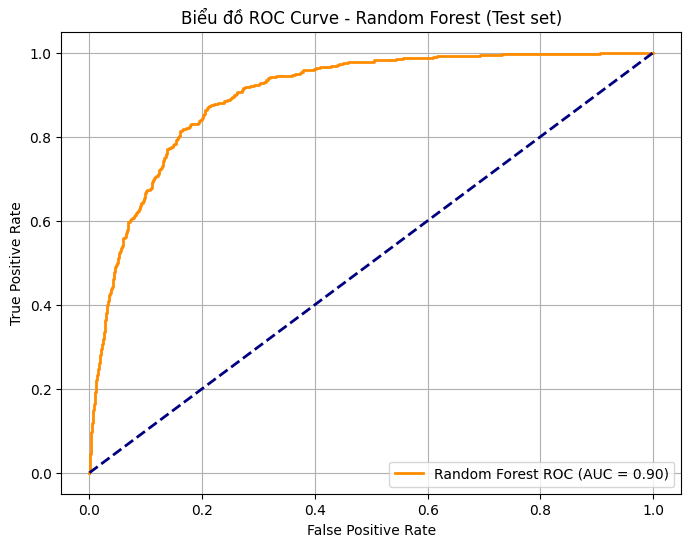

In [ ]:
#2.2.3. MÔ HÌNH RANDOM FOREST
# ----------------- TÁCH BIẾN PHỤ THUỘC VÀ ĐỘC LẬP -----------------
y = df['term_deposit']
X = df.drop(columns='term_deposit')

# Convert target variable to numerical format
y = y.map({'có': 1, 'không': 0})
# ----------------- MÃ HÓA CÁC BIẾN PHÂN LOẠI -----------------
X_encoded = pd.get_dummies(X, drop_first=True)

# ----------------- CHIA DỮ LIỆU: 60% TRAIN - 20% VALIDATION - 20% TEST -----------------
# Bước 1: Chia train (60%) và còn lại (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.4, random_state=42, stratify=y
)

# Bước 2: Chia nốt 40% còn lại thành validation (20%) và test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nKích thước tập huấn luyện (Train): {X_train.shape}")
print(f"Kích thước tập xác thực (Validation): {X_val.shape}")
print(f"Kích thước tập kiểm tra (Test): {X_test.shape}")

# ----------------- ÁP DỤNG SMOTE TRÊN TẬP HUẤN LUYỆN -----------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nSau khi áp dụng SMOTE:")
print(f"Tập huấn luyện (Train) sau SMOTE: {X_train_res.shape}")
print(f"Tỷ lệ class sau SMOTE: \n{y_train_res.value_counts()}")

# ----------------- HUẤN LUYỆN MÔ HÌNH RANDOM FOREST -----------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

# ----------------- ĐÁNH GIÁ TRÊN TẬP VALIDATION -----------------
y_val_pred = rf_model.predict(X_val)
y_val_proba = rf_model.predict_proba(X_val)[:, 1]

print("\n========== ĐÁNH GIÁ TRÊN TẬP VALIDATION ==========")
print("\n1. Classification Report (Validation):")
print(classification_report(y_val, y_val_pred))

cm_val = confusion_matrix(y_val, y_val_pred)
print("\n2. Confusion Matrix (Validation):")
print(cm_val)

# ----------------- ĐÁNH GIÁ TRÊN TẬP KIỂM TRA -----------------
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n========== ĐÁNH GIÁ TRÊN TẬP KIỂM TRA ==========")
print("\n1. Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

cm_test = confusion_matrix(y_test, y_test_pred)
print("\n2. Confusion Matrix (Test):")
print(cm_test)

# ----------------- ĐÁNH GIÁ TRÊN TẬP HUẤN LUYỆN -----------------
y_train_pred = rf_model.predict(X_train_res)

print("\n========== ĐÁNH GIÁ TRÊN TẬP HUẤN LUYỆN ==========")
print("\n1. Classification Report (Train):")
print(classification_report(y_train_res, y_train_pred))

cm_train = confusion_matrix(y_train_res, y_train_pred)
print("\n2. Confusion Matrix (Train):")
print(cm_train)

# ----------------- VẼ BIỂU ĐỒ ROC CURVE -----------------
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Biểu đồ ROC Curve - Random Forest (Test set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

- Trong mô hình Random Forest, dữ liệu được chia thành ba tập: huấn luyện (train) (60%), xác thực (validation) (20%), và kiểm tra (test) (20%). Việc chia này giúp tinh chỉnh các siêu tham số (hyperparameters) trên tập validation mà không làm ảnh hưởng đến tính khách quan của kết quả đánh giá cuối cùng trên tập test.
- Tương tự như mô hình hồi quy Logistic, kỹ thuật SMOTE và tham số class_weight='balanced' đã được sử dụng để xử lý vấn đề mất cân bằng dữ liệu, giúp cải thiện khả năng dự đoán lớp thiểu số.
- Mô hình Random Forest đạt hiệu suất gần như hoàn hảo trên tập huấn luyện, với các chỉ số precision, recall và F1-score xấp xỉ 0.96 cho cả hai lớp, nhưng đây có thể là dấu hiệu của overfitting. Trên tập xác thực và kiểm tra, mô hình duy trì hiệu suất tốt với lớp 0 (precision 0.97-0.98, recall 0.93), nhưng hiệu suất lớp 1 lại rất thấp (precision 0.29-0.33, recall 0.54-0.60).
- Ma trận nhầm lẫn cho thấy mô hình tạo ra rất nhiều dự đoán sai (False Positive) cho lớp 1, khiến nó không đáng tin cậy.
- Tuy nhiên, đường cong ROC với AUC là 0.90 lại cho thấy mô hình có khả năng phân biệt tốt giữa hai lớp, vượt trội hơn nhiều so với mô hình Logistic Regression (AUC = 0.83). Điều này chỉ ra rằng Random Forest là một lựa chọn tốt hơn, mặc dù cần phải tinh chỉnh thêm để cải thiện hiệu suất dự đoán lớp thiểu số.